# LDA on Iris dataset

In Machine Learning, LDA (Linear Discriminant Analysis) has use in 
- supervised learning—specifically classification — and
- also has applications in dimensionality reduction

### NOTE
- **LDA can be sensitive to feature scaling. It's often a good practice to scale your data before applying LDA.**
- **Target/response variable need to be encoded from string to numeric**
Here I am using it for classification

In [18]:
# SKIP I created the csv file using following:
import pandas as pd
from sklearn.datasets import load_iris

data = load_iris()
X, y = data.data, data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.to_csv('data_iris.csv', index=False)

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the breast cancer dataset
file = 'data_iris.csv'

df = pd.read_csv(file)

print(df.head(6))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
5       0  


In [20]:
from sklearn.preprocessing import StandardScaler
# Split into X and y
X = df.drop('target', axis=1)
y = df['target']

# Create the scaler
scaler = StandardScaler()

# Fit on data and transform
X_scaled = scaler.fit_transform(X)
print(f"X_scaled[:3]:\n{X_scaled[:3]}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_scaled[:3]:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]]


In [21]:
# Create an LDA instance
lda = LinearDiscriminantAnalysis()

# Fit the LDA model using the training data
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [22]:
# Predict the classes for the testing data
y_pred = lda.predict(X_test)

# Evaluate the accuracy of the LDA model
accuracy = lda.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 100.00%


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



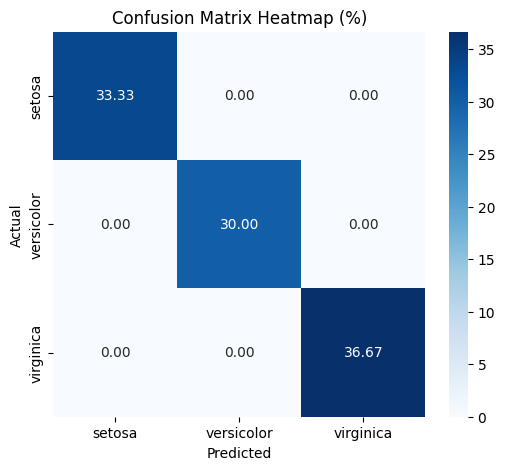

In [24]:
# OPTIONAL Now I want to see some more details about the performance metrics

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix (counts)
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Normalize confusion matrix to percentages
cm_percent = cm.astype('float') / cm.sum() * 100

# Class names manually defined (order: 0 = setosa, 1 = versicolor, 2 = virginica)
class_names = ['setosa', 'versicolor', 'virginica']

# Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap (%)')
plt.show()